In [2]:
import kagglehub
from pathlib import Path 
# Download latest version
na_folder = Path(kagglehub.dataset_download("jasonairroi/airbnb-market-data-north-america"))
eu_folder = Path(kagglehub.dataset_download("jasonairroi/airbnb-market-data-europe"))
asia_pacific_folder = Path(kagglehub.dataset_download("jasonairroi/airbnb-market-data-asia-pacific"))
latin_caribbean_folder = Path(kagglehub.dataset_download("jasonairroi/airbnb-market-data-latin-america-caribbean"))

na_listings_path = na_folder / "listings.csv"
eu_listings_path = eu_folder / "listings.csv"
asia_pacific_listings_path = asia_pacific_folder / "listings.csv"
latin_caribbean_listings_path = latin_caribbean_folder / "listings.csv"

na_past_rates_path = na_folder / "past_rates.csv"
eu_past_rates_path = eu_folder / "past_rates.csv"
asia_pacific_past_rates_path = asia_pacific_folder / "past_rates.csv"
latin_caribbean_past_rates_path = latin_caribbean_folder / "past_rates.csv"


/Users/gabrieltedja/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd
import numpy as np


na_listings = pd.read_csv(na_listings_path, sep=None, engine="python", on_bad_lines="skip")
eu_listings = pd.read_csv(eu_listings_path, sep=None, engine="python", on_bad_lines="skip")
asia_pacific_listings = pd.read_csv(asia_pacific_listings_path, sep=None, engine="python", on_bad_lines="skip")
latin_caribbean_listings = pd.read_csv(latin_caribbean_listings_path, sep=None, engine="python", on_bad_lines="skip")

na_past_rates = pd.read_csv(na_past_rates_path, sep=None, engine="python", on_bad_lines="skip")
eu_past_rates = pd.read_csv(eu_past_rates_path, sep=None, engine="python", on_bad_lines="skip")
asia_pacific_past_rates = pd.read_csv(asia_pacific_past_rates_path, sep=None, engine="python", on_bad_lines="skip")
latin_caribbean_past_rates = pd.read_csv(latin_caribbean_past_rates_path, sep=None, engine="python", on_bad_lines="skip")

na_listings["Region"] = "North America"
eu_listings["Region"] = "Europe"
asia_pacific_listings["Region"] = "Asia-Pacific"
latin_caribbean_listings["Region"] = "Latin America/Caribbean"

na_past_rates["Region"] = "North America"
eu_past_rates["Region"] = "Europe"
asia_pacific_past_rates["Region"] = "Asia-Pacific"
latin_caribbean_past_rates["Region"] = "Latin America/Caribbean"

all_listings = pd.concat([na_listings, eu_listings, asia_pacific_listings, latin_caribbean_listings], ignore_index=True)
all_past_rates = pd.concat([na_past_rates, eu_past_rates, asia_pacific_past_rates, latin_caribbean_past_rates], ignore_index=True)

In [4]:
all_listings.head()

,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city,Region
0,177833,Entire guesthouse,entire_home,https://a0.muscache.com/im/pictures/67280846-0...,36.0,c40416107927,True,38.9043,-104.973,3.0,...,0.0,0.0,8.0,0.0,82.0,90.0,United States,Colorado,Colorado Springs,North America
1,312996,Entire guesthouse,entire_home,https://a0.muscache.com/im/pictures/hosting/Ho...,34.0,62fb4136b324,True,38.8388,-104.814,2.0,...,49.5,49.5,35.0,14.0,55.0,90.0,United States,Colorado,Colorado Springs,North America
2,2237908,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/0e03770a-3...,15.0,13c8856ce8b1,True,38.8413,-104.8097,5.0,...,0.0,0.0,48.0,0.0,42.0,90.0,United States,Colorado,Colorado Springs,North America
3,2306147,Entire home,entire_home,https://a0.muscache.com/im/pictures/miso/Hosti...,16.0,8fe96865f520,True,38.8456,-104.7298,7.0,...,0.0,0.0,34.0,0.0,56.0,90.0,United States,Colorado,Colorado Springs,North America
4,2526116,Entire home,entire_home,https://a0.muscache.com/im/pictures/hosting/Ho...,39.0,d127f1078650,True,38.8368,-104.8437,8.0,...,0.0,0.0,40.0,0.0,50.0,90.0,United States,Colorado,Colorado Springs,North America


In [5]:
all_past_rates.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg,native_booked_rate_avg,native_rate_avg,native_revenue,country,state,city,Region
0,13117492,2025-02-01,4,24,0.857,1283.0,53.4,53.5,3.0,6.0,2.0,27022.0,26972.0,648031.0,Costa Rica,Limón Province,Cahuita,North America
1,13117492,2025-03-01,15,16,0.516,874.0,54.4,54.6,18.0,3.0,2.0,27693.0,27591.0,443283.0,Costa Rica,Limón Province,Cahuita,North America
2,13117492,2025-04-01,9,21,0.700,1125.0,53.6,53.6,38.0,7.0,2.0,26822.0,26822.0,562972.0,Costa Rica,Limón Province,Cahuita,North America
3,13117492,2025-05-01,31,0,0.000,0.0,52.2,NaN,NaN,NaN,1.0,NaN,26446.0,0.0,Costa Rica,Limón Province,Cahuita,North America
4,13117492,2025-06-01,30,0,0.000,0.0,60.3,NaN,NaN,NaN,1.0,NaN,30576.0,0.0,Costa Rica,Limón Province,Cahuita,North America


In [6]:
all_listings['ttm_revenue'] = pd.to_numeric(all_listings['ttm_revenue'], errors='coerce')
all_listings['ttm_occupancy'] = pd.to_numeric(all_listings['ttm_occupancy'], errors='coerce')
all_listings['rating_overall'] = pd.to_numeric(all_listings['rating_overall'], errors='coerce')
all_listings.dropna(subset=['ttm_revenue', 'ttm_occupancy', 'rating_overall'], inplace=True)
all_listings['superhost'] = all_listings['superhost'].apply(lambda x: True if (x == 'true' or x == True) else False)

In [14]:
all_listings.columns

Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'latitude', 'longitude',
       'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities',
       'instant_book', 'professional_management', 'min_nights',
       'cancellation_policy', 'currency', 'cleaning_fee', 'extra_guest_fee',
       'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
       'rating_cleanliness', 'rating_communication', 'rating_location',
       'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate',
       'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
       'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
       'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days',
       'ttm_available_days', 'ttm_total_days', 'l90d_revenue',
       'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',
       'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar',
 

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

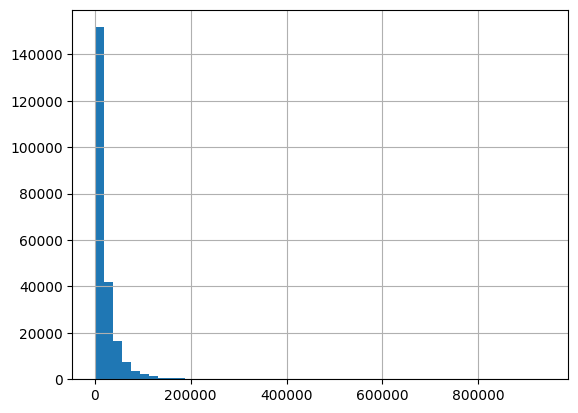

In [8]:
all_listings['ttm_revenue'].hist(bins=50)
plt.show()

In [9]:
all_listings.groupby('superhost')[['ttm_revenue','ttm_occupancy','rating_overall']].mean()

,ttm_revenue,ttm_occupancy,rating_overall
superhost,,,
False,15128.685547,0.230131,4.717700
True,25459.381153,0.386355,4.850788


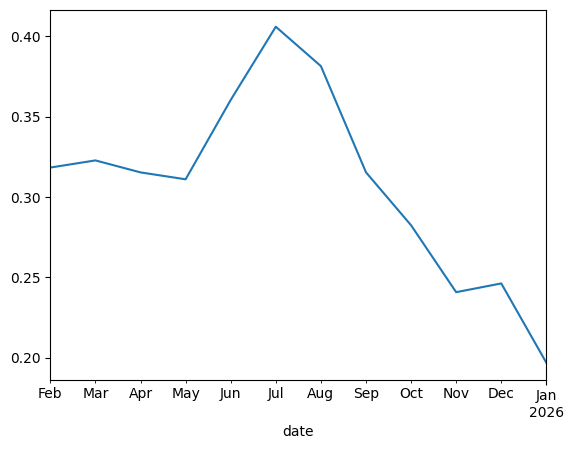

In [10]:
all_past_rates['date'] = pd.to_datetime(all_past_rates['date'])
monthly = all_past_rates.groupby(all_past_rates['date'].dt.to_period('M'))['occupancy'].mean()
monthly.plot()
plt.show()

<Axes: >

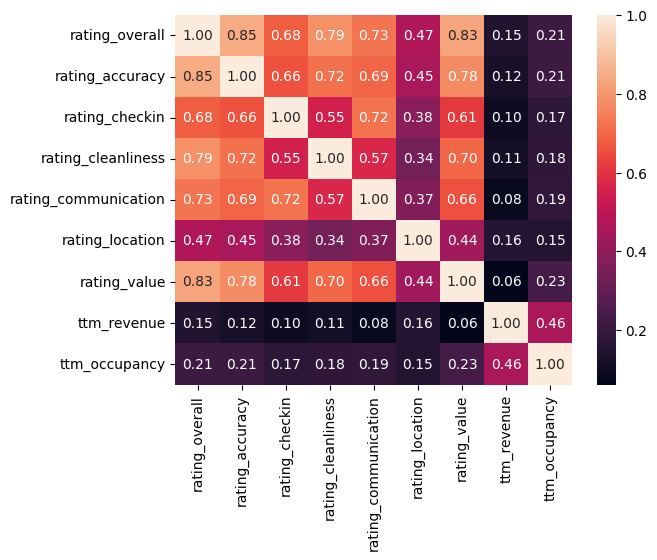

In [11]:
rating_cols = [c for c in all_listings.columns if 'rating_' in c] + ['ttm_revenue', 'ttm_occupancy']
sns.heatmap(all_listings[rating_cols].corr(), annot=True, fmt='.2f')

In [12]:
all_listings.groupby('Region')[['ttm_revenue','ttm_occupancy','rating_overall']].mean()

,ttm_revenue,ttm_occupancy,rating_overall
Region,,,
Asia-Pacific,13357.123917,0.292172,4.759683
Europe,19017.888914,0.319556,4.766966
Latin America/Caribbean,9068.212265,0.249312,4.809365
North America,30869.988417,0.332559,4.804651


From this you can infer airbnbs are more popular in North America, as opposed to other regions where people may prefer hotels.

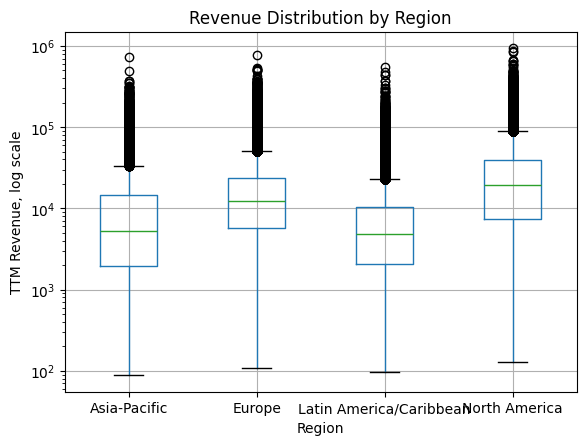

In [13]:
all_listings.boxplot(column="ttm_revenue", by="Region")
plt.yscale("log")
plt.title("Revenue Distribution by Region")
plt.suptitle("")
plt.ylabel("TTM Revenue, log scale")
plt.show()

In [24]:
all_listings["city"].value_counts().head(20)

city
Naples                581
Birmingham            507
Cartagena             505
La Paz                500
London                492
Richmond              466
Oxford                407
Arlington             375
San Jose              300
Cincinnati            300
St. Louis             300
Lisbon                300
Liverpool             300
Athens                300
Venice                300
South Padre Island    299
León                  299
Seattle               299
Oklahoma City         299
Chicago               299
Name: count, dtype: int64

In [20]:
na_cities = all_listings[all_listings["Region"] == "North America"]["city"].value_counts().head(20)
na_cities

city
Richmond              466
Arlington             375
San Jose              300
Cincinnati            300
St. Louis             300
South Padre Island    299
León                  299
Seattle               299
Oklahoma City         299
Chicago               299
Pittsburgh            299
Monterrey             299
Charlotte             299
San Francisco         299
Boston                299
Antigua Guatemala     299
Los Angeles           298
Breckenridge          298
San Diego             298
El Paso               298
Name: count, dtype: int64

In [22]:
eu_cities = all_listings[all_listings["Region"] == "Europe"]["city"].value_counts().head(20)
eu_cities

city
Lisbon                         300
Liverpool                      300
Athens                         300
Venice                         300
Chamonix-Mont-Blanc            299
Rome                           299
London                         299
Lille                          299
Barcelona                      299
City of Zagreb                 299
Valencia                       299
Lagos                          299
Annecy                         299
Bristol                        299
Leipzig                        298
Budapest                       298
Florence                       298
Wrocław                        298
Thessaloniki Municipal Unit    298
Verona                         298
Name: count, dtype: int64

In [23]:
asia_pacific_cities = all_listings[all_listings["Region"] == "Asia-Pacific"]["city"].value_counts().head(20)
asia_pacific_cities

city
Tokyo                        299
Sydney                       297
Kyoto                        297
Greater Brisbane             297
Taipei                       297
Adelaide                     296
Waitematā                    296
Bangkok                      296
Gold Coast City              295
Osaka                        295
Melbourne                    294
Ipoh                         294
Special Region of Jakarta    293
Johor Bahru                  293
Christchurch                 293
Makati                       293
George Town                  293
Tagaytay                     293
Patong                       292
Chiang Mai                   292
Name: count, dtype: int64

In [25]:
latin_caribbean_cities = all_listings[all_listings["Region"] == "Latin America/Caribbean"]["city"].value_counts().head(20)
latin_caribbean_cities

city
Goiânia                       299
Plano Piloto                  299
Rio de Janeiro                298
Medellín                      297
Santiago de los Caballeros    297
Cuenca                        297
São Sebastião                 296
Paraty                        296
Curitiba                      296
São Paulo                     296
Distrito de Cusco             296
Havana                        295
Lima Metropolitan Area        295
Maceió                        295
Cartagena                     295
Florianópolis                 295
Ilhabela                      295
Santiago                      295
Las Condes                    295
Campos do Jordão              295
Name: count, dtype: int64

In [35]:
all_listings[all_listings["city"] == "Naples"][["city", "Region"]].value_counts()


city    Region       
Naples  Europe           291
        North America    290
Name: count, dtype: int64

In [33]:
all_listings[all_listings["city"] == "La Paz"][["city", "Region"]].value_counts()

city    Region                 
La Paz  North America              296
        Latin America/Caribbean    204
Name: count, dtype: int64

In [34]:
all_listings[all_listings["city"] == "Cartagena"][["city", "Region"]].value_counts()

city       Region                 
Cartagena  Latin America/Caribbean    295
           Europe                     210
Name: count, dtype: int64

Above cells are intended to check for cities with the same name.